<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB00 · El mapa del conjunto

**Fase 0 · Lección 1 — Probar el plato entero**

> Bienvenido. Este es el primer notebook de una ruta larga que va **de cero a
> profesional**: al final sabrás entrenar la "mente" de un robot que anda sobre dos
> piernas, como los humanoides que ves en los vídeos de las empresas de robótica.
> No hace falta que tengas ni título de ingeniería ni conocimientos previos de robótica.
> Solo hace falta leer sin prisa y trastear con el código.

En esta primera lección **no** vamos a entrenar nada todavía. Vamos a hacer algo más
importante: **entender el mapa entero** antes de estudiar cada pieza. Igual que antes de
cocinar un plato complicado conviene ver una foto del plato terminado, aquí vamos a ver
todas las piezas del proceso de una sola vez, aunque cada una la estudiaremos a fondo más
adelante.

## 0 · Cómo funciona este curso (léelo una vez)

- **Se lee como un libro.** Cada notebook es una lección larga: primero el problema, luego
  la idea con un ejemplo cotidiano, después la notación y el código, y siempre un caso que
  **sale mal a propósito** (esa parte es oro: es donde de verdad se aprende).
- **Nada se da por sabido.** La primera vez que aparece un término, se explica. Al final de
  cada notebook hay un **apéndice de Python** que explica desde cero todo el código que se
  ha usado. Es un 2×1: aprendes robótica *y* aprendes a programar.
- **Las matemáticas van dentro.** Cuando haga falta un poco de matemáticas (vectores,
  derivadas, probabilidad…), se explican aquí mismo, desde cero y con analogías. No
  necesitas material aparte.
- **Los ejercicios van resueltos.** Después de las preguntas encontrarás la solución
  escondida bajo un desplegable "▶ Solución". Intenta responder tú primero; luego ábrela.
- **Dónde se ejecuta cada cosa.** Los notebooks marcados como *CPU* corren en tu Raspberry
  Pi o en tu portátil. Los marcados con **▶ En Colab** necesitan una tarjeta gráfica (GPU)
  y se ejecutan gratis en Google Colab; los verás más adelante.

Vamos allá.

## 1 · El problema: quiero que un robot ande

Parece fácil, porque tú andas sin pensar. Pero andar es de lo más difícil que hace un
cuerpo. Prueba a describir **con instrucciones exactas** cómo dar un paso: cuánto doblar la
rodilla, cuánta fuerza en el tobillo, cómo inclinar el tronco para no caer, qué corregir si
el suelo está un poco inclinado, qué hacer si alguien te empuja… Nadie sabe escribir esas
instrucciones a mano para un robot. Son demasiadas, cambian a cada instante y dependen de
mil detalles.

Un robot bípedo es, además, **inestable por naturaleza**: si no corrige su postura muchas
veces por segundo, se cae, igual que un palo de escoba que intentas sostener de pie sobre la
palma de la mano. Un coche con cuatro ruedas se queda quieto solo; un bípedo, no.

Entonces, si no podemos **escribir** las instrucciones a mano, ¿de dónde salen?

> **La idea central de todo el curso:** en vez de *escribir* cómo andar, dejamos que el robot
> lo **aprenda probando**, millones de veces, en un mundo simulado donde caerse no cuesta nada.
> A eso se le llama **aprendizaje por refuerzo**. Lo que el robot aprende —su "manera de
> decidir qué hacer"— se llama **política**.

## 2 · Las seis piezas (el dibujo que rellenaremos durante meses)

Todo el proceso, de principio a fin, tiene **seis piezas**. Este es el mapa completo del
curso. No hace falta entenderlo del todo aún; volverás a este dibujo muchas veces.

```
   ┌──────────────────────────────────────────────────────────────────────┐
   │                     EL PLATO ENTERO (la ruta completa)                 │
   └──────────────────────────────────────────────────────────────────────┘

   (1) EL ROBOT                     (2) EL SIMULADOR
   ┌───────────────┐                ┌────────────────────────────┐
   │   cabeza      │                │  un mundo de mentira con    │
   │  ┌─────┐      │   se describe  │  gravedad, suelo, choques.  │
   │  │torso│──brazos            →  │  Aquí el robot puede caerse │
   │  └──┬──┘      │   dentro de    │  un millón de veces gratis. │
   │   ┌─┴─┐       │                │  Nosotros usaremos MuJoCo.  │
   │  pierna pierna│                └────────────────────────────┘
   │   │   │       │
   │  pie  pie     │
   └───────────────┘

                 ┌───────────────── EL BUCLE (se repite sin parar) ─────────────────┐
                 │                                                                   │
                 │   OBSERVACIÓN            (3) POLÍTICA            ACCIÓN            │
                 │   (qué percibe:   ───►   la "mente":     ───►   (qué ordena a     │
                 │   ángulos, veloc.,       una red que              los motores:    │
                 │   inclinación)           decide                   ir a este ángulo)│
                 │        ▲                                              │           │
                 │        │                                              ▼           │
                 │        │            (2) EL SIMULADOR avanza la física un pasito   │
                 │        │                y dice cómo queda el robot                │
                 │        └──────────────────────────────────────────────┘          │
                 │                             │                                      │
                 │                             ▼                                      │
                 │                   (4) RECOMPENSA: un número que dice               │
                 │                   "esto ha estado bien / mal"                      │
                 └───────────────────────────────────────────────────────────────────┘
                                               │
                                               ▼
   (5) ENTRENAMIENTO                    (6) SIM-TO-REAL
   ┌────────────────────────────┐      ┌────────────────────────────┐
   │ repetir el bucle millones   │      │ coger la política ya        │
   │ de veces y, con las         │  →   │ entrenada y meterla en un   │
   │ recompensas, AJUSTAR la     │      │ robot FÍSICO de verdad.     │
   │ política para ganar más.    │      │ La pieza más difícil y la   │
   │ Aquí es donde hace falta GPU│      │ más valiosa del portafolio. │
   └────────────────────────────┘      └────────────────────────────┘
```

Léelo de nuevo despacio. Fíjate en que el corazón de todo es **el bucle**: el robot
observa, la política decide, el simulador aplica la acción y devuelve una recompensa. Ese
bucle es literalmente lo que vamos a programar y entrenar.

## 3 · Las seis piezas, una a una

**(1) El robot.** Aquí, un modelo de robot: una descripción de qué piezas rígidas tiene
(torso, muslos, pantorrillas, pies…), cómo se unen por **articulaciones** (las juntas que
giran, como tu rodilla) y qué **motores** mueven cada articulación. En simulación es un
fichero de texto que el simulador lee. Más adelante será un robot real, como el humanoide
Unitree G1.

**(2) El simulador.** Un programa que imita la física: gravedad, el suelo, los choques, la
fricción. Le dices "los motores empujan así" y te contesta "entonces el robot queda
inclinado así y el pie toca el suelo aquí". Usaremos **MuJoCo**, el simulador estándar en
investigación de robots. Su gran ventaja: caerse en simulación no rompe nada ni cuesta
dinero, así que el robot puede fallar millones de veces.

**(3) La política.** La "mente" del robot. Es una **función**: recibe la **observación**
(lo que el robot percibe: ángulos de sus articulaciones, velocidades, cuánto está inclinado)
y devuelve la **acción** (qué hacer con los motores). En este curso la política será una
**red neuronal**, que es lo que estudiaremos en la Fase 2. De momento basta con verla como
una caja: entra "cómo estoy", sale "qué hago".

**(4) La recompensa.** Un número que puntúa cada instante. Por ejemplo: "+1 por cada paso
de tiempo que sigues de pie, +velocidad si avanzas hacia delante, −algo si gastas
demasiada energía". Entrenar es, literalmente, **buscar la política que acumula más
recompensa**. Diseñar bien la recompensa es un arte: en la sección "lo que sale mal" verás
lo fácil que es que el robot te haga trampa.

**(5) El entrenamiento.** Repetir el bucle un número enorme de veces y, a partir de las
recompensas, **ajustar** poco a poco la política para que la próxima vez lo haga mejor.
Esto es lo que consume potencia de cálculo y por lo que necesitaremos una **GPU** (lo
veremos en el NB01). El algoritmo estrella se llama **PPO**, y en la Fase 3 lo
programaremos nosotros mismos.

**(6) Sim-to-real.** Coger la política ya entrenada en el simulador y meterla en un robot
**físico**. Es la pieza más difícil (el mundo real nunca es idéntico a la simulación) y la
más valiosa para un portafolio. Es la Fase 7.

## 4 · Ves el robot (esto sí corre en tu Pi)

Basta de dibujos. Vamos a **abrir el simulador y ver un humanoide de verdad**. Todavía no
sabe andar (no lo hemos entrenado), pero quiero que compruebes con tus propios ojos que las
piezas (1) el robot y (2) el simulador existen y funcionan en tu máquina.

El código de debajo hace esto:

1. Le dice a MuJoCo que dibuje **sin pantalla** (tu Pi no tiene monitor conectado a este
   proceso), usando un modo llamado `egl`.
2. Abre un **entorno** de robot ya hecho, `Humanoid-v5`: un humanoide con 17 motores.
3. Lo coloca en su postura inicial y **le hace una foto**.

Cada línea está comentada. Si algo del código te suena a chino, no te preocupes: al final
del notebook hay un apéndice que lo explica desde cero.

In [1]:
# --- Preparar el dibujo sin pantalla -------------------------------------
# MuJoCo necesita saber cómo dibujar. En un ordenador con monitor usaría la
# pantalla; en la Raspberry Pi (sin monitor para este proceso) le decimos que
# use 'egl', un modo que dibuja "en memoria". Esto DEBE ir antes de importar
# mujoco o gymnasium.
import os
os.environ["MUJOCO_GL"] = "egl"

import numpy as np                 # cálculo con números y listas de números
import gymnasium as gym            # colección de "entornos" (robots + mundo) ya hechos
import matplotlib.pyplot as plt    # para mostrar imágenes

# --- Abrir el entorno del humanoide --------------------------------------
# gym.make(...) construye un "entorno": el robot metido en su mundo de física.
# render_mode="rgb_array" significa "quiero poder pedirte fotos en color".
env = gym.make("Humanoid-v5", render_mode="rgb_array")

# reset() coloca el robot en su postura inicial. La semilla (seed) fija el azar
# para que el resultado sea siempre el mismo (reproducible).
observacion, info = env.reset(seed=0)

print("El robot ya está en su mundo.")
print("Tamaño de la OBSERVACIÓN (lo que percibe):", observacion.shape, "números")
print("Tamaño de la ACCIÓN (lo que puede ordenar):", env.action_space.shape, "motores")

El robot ya está en su mundo.
Tamaño de la OBSERVACIÓN (lo que percibe): (348,) números
Tamaño de la ACCIÓN (lo que puede ordenar): (17,) motores


Fíjate en lo que ha impreso: la **observación** tiene 348 números (todo lo que el robot
"siente" en un instante) y la **acción** tiene 17 números (una orden para cada uno de sus
17 motores). Esos dos números —cuántas entradas y cuántas salidas— definen el "tamaño" del
problema. La política tendrá que convertir esos 348 números de entrada en esos 17 de salida.

Ahora hagámosle una foto en su postura inicial:

La foto es una rejilla de (480, 480, 3) (alto, ancho, colores R-G-B)


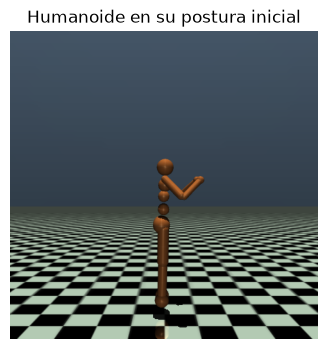

In [2]:
# env.render() devuelve una foto: una rejilla de píxeles (alto x ancho x 3 colores).
foto = env.render()
print("La foto es una rejilla de", foto.shape, "(alto, ancho, colores R-G-B)")

plt.figure(figsize=(4, 4))
plt.imshow(foto)          # dibuja la rejilla de píxeles como imagen
plt.axis("off")           # sin ejes de gráfica, que es una foto
plt.title("Humanoide en su postura inicial")
plt.show()

Ahí lo tienes: un humanoide, de pie, en un mundo con suelo y gravedad, dentro de tu
Raspberry Pi. Las piezas (1) y (2) del mapa ya no son un dibujo abstracto: son código que
acabas de ejecutar.

## 5 · Lo que sale mal: una política que decide al azar

Ahora la pieza (3), la **política**. Todavía no tenemos ninguna entrenada, así que vamos a
poner la peor política posible: **decidir las acciones al azar**. Es como si el robot moviera
los 17 motores a lo loco, sin ton ni son.

Esto es el ejemplo que "sale mal" de esta lección, y es importantísimo verlo: te enseña
**por qué** hace falta entrenar. Vamos a dejar que el robot actúe al azar durante unos
instantes y a guardar los fotogramas en un GIF para verlo moverse.

In [3]:
import imageio  # para guardar una secuencia de fotos como GIF animado

env.reset(seed=0)
fotogramas = []          # aquí iremos guardando cada foto
pasos_vivo = 0           # cuántos pasos aguanta antes de "morir" (caerse)
sigue_vivo = True

for paso in range(80):                       # intentamos 80 pasos de tiempo
    accion = env.action_space.sample()       # <-- ACCIÓN AL AZAR (la mala política)
    obs, recompensa, terminado, truncado, info = env.step(accion)  # el simulador avanza
    fotogramas.append(env.render())          # guardamos la foto de este instante
    if sigue_vivo:
        pasos_vivo += 1
    if terminado:            # 'terminado' = el robot se ha caído (episodio acabado)
        sigue_vivo = False

print(f"Con acciones al azar, el robot aguantó {pasos_vivo} pasos antes de caerse.")
print(f"(un episodio entero sano puede durar 1000 pasos)")

# Guardamos el GIF en la carpeta de recursos del proyecto
os.makedirs("assets", exist_ok=True)
ruta_gif = "assets/nb00_humanoide_azar.gif"
imageio.mimsave(ruta_gif, fotogramas, fps=20, loop=0)
print("GIF guardado en:", ruta_gif)

Con acciones al azar, el robot aguantó 21 pasos antes de caerse.
(un episodio entero sano puede durar 1000 pasos)


GIF guardado en: assets/nb00_humanoide_azar.gif


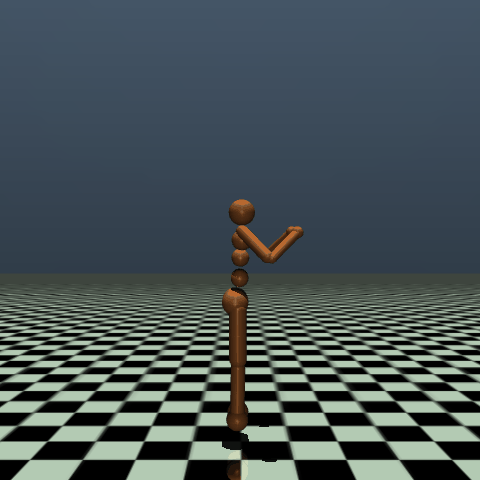

In [4]:
# Mostramos el GIF dentro del notebook
from IPython.display import Image
Image(filename="assets/nb00_humanoide_azar.gif")

Como era de esperar: **se desploma casi al instante**. Moverse al azar no es andar; es
convulsionar y caer. Y aquí está la lección de fondo:

> El robot y el simulador nos los dan hechos. La física es la que es. Lo único que
> convierte a ese montón de motores temblorosos en algo que **anda** es una **buena
> política**. Y una buena política no se escribe a mano: se **entrena**. Ese es el trabajo
> que aprenderás a hacer.

Toda la ruta consiste en sustituir ese `env.action_space.sample()` (elegir al azar) por
una red neuronal entrenada que elige **bien**.

In [5]:
# Buena práctica: cerrar el entorno cuando terminamos (libera recursos).
env.close()
print("Entorno cerrado.")

Entorno cerrado.


## 6 · Dónde vive cada pieza en la ruta

Para que el mapa no quede en el aire, mira en qué fase estudiaremos cada pieza a fondo:

| Pieza del mapa | ¿Dónde la dominas? |
|---|---|
| (3) Política = red neuronal | **Fase 2** (redes neuronales) |
| (4) Recompensa y (5) entrenamiento (RL, PPO) | **Fase 3** (aprendizaje por refuerzo) |
| (1) El robot: su física, articulaciones, control | **Fase 4** (el cuerpo del robot) |
| (2)+(3)+(4)+(5) juntos, con un humanoide de verdad | **Fase 5** (entrenar bípedos) |
| (6) Sim-to-real, robot físico | **Fase 7** (hardware real) |

Y antes de todo eso, la **Fase 1** te dará una base sólida de programación para que el
código deje de ser un obstáculo. La Fase 0 (esta) es solo para ver el plato entero y
comprobar que te engancha.

## 7 · Preguntas de comprensión

Intenta responder con tus propias palabras antes de abrir cada solución. Una respuesta tuya
equivocada vale más que una copiada.

**P1.** ¿Por qué decimos que un robot bípedo es "inestable por naturaleza" y en qué se
diferencia de un coche parado?

**P2.** Explica con tus palabras qué es la **política** y cuáles son su entrada y su salida.

**P3.** En el código, ¿qué representaba `env.action_space.sample()` y por qué el robot se caía?

**P4.** ¿Por qué entrenamos en un **simulador** en lugar de directamente en un robot real?

**P5.** De las seis piezas del mapa, ¿cuál dirías que es "la mente" del robot y cuál "el
mundo de mentira donde practica"?

<details>
<summary>▶ Solución P1</summary>

Un bípedo tiene su masa alta y apoyada sobre una base muy pequeña (dos pies, a veces solo
uno mientras da un paso). Si no corrige su postura muchas veces por segundo, la gravedad lo
tumba, como un palo de escoba sobre la palma. Un coche parado tiene cuatro ruedas separadas
y su masa baja: la base de apoyo es grande y estable, así que se queda quieto sin hacer
nada. El bípedo necesita **control activo constante**; el coche no.
</details>

<details>
<summary>▶ Solución P2</summary>

La política es la "mente" o la regla de decisión del robot. Su **entrada** es la
**observación** (lo que percibe: ángulos de articulaciones, velocidades, inclinación…). Su
**salida** es la **acción** (qué ordenar a los motores). Formalmente es una función
"observación → acción", y en este curso esa función será una red neuronal entrenada.
</details>

<details>
<summary>▶ Solución P3</summary>

`env.action_space.sample()` elige una acción **al azar** dentro de las posibles: mueve los
17 motores a valores aleatorios en cada paso. Es la "política más tonta". El robot se caía
porque mover los motores al azar no tiene ninguna relación con mantener el equilibrio ni
avanzar; es puro temblor descoordinado, y la gravedad lo tumba enseguida.
</details>

<details>
<summary>▶ Solución P4</summary>

Porque entrenar exige **fallar muchísimas veces** (millones). En un robot real, cada caída
puede romper piezas caras, gasta tiempo y es peligroso, y no puedes repetir el mismo intento
de forma idéntica. En el simulador caerse no cuesta nada, va mucho más rápido que el tiempo
real, se puede repetir exactamente (con semillas) y se pueden correr muchos robots a la vez.
Por eso se entrena en simulación y solo al final se pasa al robot real (sim-to-real).
</details>

<details>
<summary>▶ Solución P5</summary>

"La mente" es la **(3) política**. "El mundo de mentira donde practica" es el **(2)
simulador**.
</details>

## 8 · Posdata

Si en algún momento te has perdido, dime el **número de apartado** y la **frase exacta**
donde ocurrió, y lo reescribo de otra forma. Si una parte no te ha quedado clara, la culpa
es del texto, no tuya.

En el **NB01** entenderemos qué es exactamente un notebook y una celda (esto que estás
usando), qué es Colab y **por qué una GPU acelera tanto el entrenamiento** —con una
demostración medida aquí en tu Pi.

---

## Apéndice · El Python de este notebook, desde cero

Este curso es un 2×1: aprendes robótica y, de paso, a programar en Python. Aquí repasamos
**todo** lo que ha aparecido arriba, sin dar nada por sabido.

### A) `import` — traer herramientas
Python trae poquísimo de serie. Las herramientas extra viven en **módulos** que se "traen"
con `import`:
```python
import numpy as np      # trae numpy y lo apodamos 'np' para escribir menos
import gymnasium as gym  # trae gymnasium y lo apodamos 'gym'
```
A partir de ahí, `np.algo` significa "la cosa `algo` de numpy".

### B) `os.environ["MUJOCO_GL"] = "egl"` — un ajuste del sistema
`os` es el módulo que habla con el sistema operativo. `os.environ` es como un diccionario de
"variables de entorno" (ajustes globales). Aquí ponemos el ajuste `MUJOCO_GL` a `"egl"` para
decirle a MuJoCo cómo dibujar. Debe hacerse **antes** de importar mujoco/gymnasium porque el
ajuste se lee en ese momento.

### C) Llamar a una función y recibir varios resultados
```python
observacion, info = env.reset(seed=0)
```
`env.reset(...)` es una **función**: le pasas datos entre paréntesis (`seed=0`) y te
devuelve resultados. Aquí devuelve **dos** cosas a la vez, y Python las reparte en dos
variables separadas por la coma. `seed=0` es un **argumento con nombre**: "el argumento
llamado seed vale 0".

### D) `.shape` — el tamaño
`observacion.shape` te dice la **forma** (cuántos números tiene, en qué disposición). Es un
dato, no una función, por eso no lleva paréntesis.

### E) El bucle `for`
```python
for paso in range(80):
    ...
```
`range(80)` son los números 0, 1, 2, …, 79. El bucle repite el bloque indentado (el que va
más a la derecha) una vez por cada número. `paso` va tomando cada valor. La **indentación**
(los espacios a la izquierda) es la que marca qué líneas están "dentro" del bucle: en Python
los espacios importan de verdad.

### F) Listas y `.append()`
```python
fotogramas = []            # una lista vacía
fotogramas.append(env.render())   # añade un elemento al final
```
Una **lista** es una colección ordenada de cosas. `.append(x)` mete `x` al final. Así vamos
acumulando las fotos, una por paso.

### G) `env.step(accion)` — el corazón del bucle
Devuelve **cinco** cosas: la nueva observación, la recompensa, si el episodio ha
`terminado` (el robot se cayó), si se ha `truncado` (se acabó el tiempo) e `info` (datos
extra). Los repartimos en cinco variables.

### H) `if` — decidir
```python
if terminado:
    sigue_vivo = False
```
`if` ejecuta el bloque de dentro solo si la condición es verdadera. `terminado` es un valor
booleano (`True`/`False`), así que se puede usar directamente como condición.

### I) f-strings — texto con valores metidos
```python
print(f"aguantó {pasos_vivo} pasos")
```
Una cadena de texto que empieza con `f"..."` permite meter el valor de una variable dentro,
escribiéndola entre llaves `{}`. Muy cómodo para mensajes.

### J) matplotlib e IPython.display
`plt.imshow(foto)` dibuja una rejilla de píxeles como imagen; `plt.axis("off")` quita los
ejes; `plt.show()` la muestra. `Image(filename=...)` (de `IPython.display`) muestra un
fichero de imagen —aquí, el GIF animado— dentro del notebook.

Con esto entiendes **cada línea** de código de este notebook. En los siguientes iremos
ampliando el apéndice con lo nuevo que aparezca.